# Models analyses

1. Import models

In [162]:
import pickle
from pathlib import Path

model_paths = {
    "RF no-odds": Path("../models/rf_no_odds_model.pkl"),
    "RF with-odds": Path("../models/rf_with_odds_model.pkl"),
    "XGB no-odds": Path("../models/xgb_no_odds_model.pkl"),
    "XGB with-odds": Path("../models/xgb_with_odds_model.pkl"),
}

models = {}
for name, path in model_paths.items():
    with open(path, "rb") as f:
        models[name] = pickle.load(f)


2. Import testing set

In [170]:
import numpy as np, pandas as pd
from IPython.display import display

TESTING_PATH = "../data/testing/tennis_testing.xlsx"

test_set = pd.read_excel(TESTING_PATH)

target = "y"
y_test = test_set[target]

print(f"Loaded prepared test set with {len(test_set)} rows")


Loaded prepared test set with 16482 rows


### Baselines

In [ ]:
def baseline_accuracy(name, prediction, valid_mask, y_test):
    """Accuracy of a prediction rule, computed only on matches where it applies."""
    accuracy = (prediction[valid_mask] == y_test[valid_mask]).mean()
    coverage = valid_mask.mean()
    print(f"{name}: {accuracy:.2%}  (coverage: {coverage:.1%})")
    return accuracy


# Majority class: whichever class (0 or 1) is more common in the test set.
maj_acc = y_test.value_counts(normalize=True).max()
print(f"Majority class: {maj_acc:.2%}")

valid_odds = test_set["Odds_1"].notna() & test_set["Odds_2"].notna() & (test_set["Odds_1"] != test_set["Odds_2"])
baseline_accuracy("Market (odds)", test_set["Odds_1"] < test_set["Odds_2"], valid_odds, y_test)

baseline_accuracy("Ranking", test_set["Rank_Log_Ratio"] > 0, test_set["Rank_Log_Ratio"].notna(), y_test)
baseline_accuracy("Points", test_set["Points_Log_Ratio"] > 0, test_set["Points_Log_Ratio"].notna(), y_test)


Majority class: 50.16%
Market (odds): 68.51%  (coverage: 97.1%)
Ranking: 63.65%  (coverage: 99.8%)
Points: 63.38%  (coverage: 99.8%)


np.float64(0.6338216521791988)

## Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    log_loss,
    roc_auc_score,
)


def get_model_data(model, test_set):
    model_features = list(model.feature_names_in_)
    X = test_set[model_features]
    y = test_set["y"]
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return model_features, X, y, proba, pred


def evaluate_model(name, model, test_set):
    model_features, X, y, proba, pred = get_model_data(model, test_set)

    print(f"{name}")
    print(" Accuracy:", f"{accuracy_score(y, pred):.2%}")
    print(" ROC AUC:", f"{roc_auc_score(y, proba):.4f}")
    print(" Log loss:", f"{log_loss(y, proba):.4f}")
    print(" Confusion matrix:")
    print(" " + str(confusion_matrix(y, pred)))
    print()

    return {
        "name": name,
        "features": model_features,
        "X": X,
        "y": y,
        "proba": proba,
        "pred": pred,
    }
    
results = {name: evaluate_model(name, model, test_set) for name, model in models.items()}

RF no-odds
 Accuracy: 64.94%
 ROC AUC: 0.7132
 Log loss: 0.6173
 Confusion matrix:
 [[5433 2835]
 [2943 5271]]

RF with-odds
 Accuracy: 67.09%
 ROC AUC: 0.7384
 Log loss: 0.5991
 Confusion matrix:
 [[5619 2649]
 [2776 5438]]

XGB no-odds
 Accuracy: 65.05%
 ROC AUC: 0.7132
 Log loss: 0.6213
 Confusion matrix:
 [[5484 2784]
 [2977 5237]]

XGB with-odds
 Accuracy: 67.28%
 ROC AUC: 0.7398
 Log loss: 0.5986
 Confusion matrix:
 [[5596 2672]
 [2721 5493]]



## Feature Usage

In [ ]:
def source_feature_name(transformed_name, model_features):
    # Map transformed one-hot and missing-indicator names back to source columns.
    if transformed_name.startswith("num__missingindicator_"):
        return transformed_name.removeprefix("num__missingindicator_")
    if transformed_name.startswith("num__"):
        return transformed_name.removeprefix("num__")
    if transformed_name.startswith("cat__"):
        encoded = transformed_name.removeprefix("cat__")
    elif transformed_name.startswith("high_cardinality__"):
        encoded = transformed_name.removeprefix("high_cardinality__")
    else:
        return transformed_name

    for feature in model_features:
        if encoded.startswith(f"{feature}_"):
            return feature
    return encoded


def feature_usage(name, model, top_n=15):
    model_features = list(model.feature_names_in_)
    transformed_names = model[:-1].get_feature_names_out()
    estimator = model.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
        column = "Importance"
    else:
        values = np.abs(estimator.coef_[0])
        column = "Abs_Coefficient"

    usage = pd.DataFrame({"Feature": transformed_names, column: values})
    usage["Source_Feature"] = usage["Feature"].map(
        lambda feature: source_feature_name(feature, model_features)
    )

    usage_by_source = (
        usage.groupby("Source_Feature", as_index=False)[column]
        .sum()
        .sort_values(column, ascending=False)
    )

    print(f"{name} feature usage")
    display(usage_by_source.head(top_n))

for name, model in models.items():
    feature_usage(name, model)


RF no-odds feature usage


,Source_Feature,Importance
16,Surface_Elo_Diff,0.210778
3,Elo_Diff,0.204320
10,Rank_Log_Ratio,0.191304
9,Points_Log_Ratio,0.170476
2,Dominance_Form_Diff,0.058966
11,Recent_Form_Diff,0.030354
12,Recent_Surface_Form_Diff,0.026045
5,H2H_Diff,0.020569
0,Age_Diff,0.019282
4,Fatigue_Diff,0.014518


RF with-odds feature usage


,Source_Feature,Importance
9,Odds_Log_Ratio,0.303185
3,Elo_Diff,0.154351
17,Surface_Elo_Diff,0.146493
10,Points_Log_Ratio,0.115623
11,Rank_Log_Ratio,0.108400
2,Dominance_Form_Diff,0.043515
12,Recent_Form_Diff,0.024784
13,Recent_Surface_Form_Diff,0.021206
5,H2H_Diff,0.014977
0,Age_Diff,0.014649


XGB no-odds feature usage


,Source_Feature,Importance
17,Tournament,0.294599
16,Surface_Elo_Diff,0.181929
13,Round,0.090696
14,Series,0.082701
9,Points_Log_Ratio,0.076162
10,Rank_Log_Ratio,0.056173
15,Surface,0.049390
3,Elo_Diff,0.038806
0,Age_Diff,0.025891
2,Dominance_Form_Diff,0.018601


XGB with-odds feature usage


,Source_Feature,Importance
9,Odds_Log_Ratio,0.323786
18,Tournament,0.291576
15,Series,0.087834
14,Round,0.079550
16,Surface,0.055314
0,Age_Diff,0.024523
10,Points_Log_Ratio,0.017267
12,Recent_Form_Diff,0.012636
17,Surface_Elo_Diff,0.012105
2,Dominance_Form_Diff,0.011299


### Feature distribution

In [167]:
for name, res in results.items():
    comparison_df = pd.DataFrame({
        "Correct": res["pred"] == res["y"],
        "Elo_Diff": test_set["Elo_Diff"],
        "Odds_Diff": test_set["Odds_Diff"]
    })
    
    print(f"\n--- {name}: Feature Distribution (Correct vs Wrong) ---")
    display(comparison_df.groupby("Correct")[["Elo_Diff", "Odds_Diff"]].describe())


--- RF no-odds: Feature Distribution (Correct vs Wrong) ---


Elo_Diff                                                          \
           count      mean         std         min         25%       50%   
Correct                                                                    
False     5778.0  1.218418  123.612319 -618.660546  -76.849844  1.234823   
True     10704.0  0.096750  172.482477 -610.043318 -115.033961  2.662930   

                                Odds_Diff                                   \
                75%         max     count      mean       std    min   25%   
Correct                                                                      
False     79.069102  543.267207    5743.0 -0.016831  2.031586 -27.99 -0.97   
True     113.046604  681.473768   10668.0  0.023520  4.970082 -66.00 -1.84   

                            
         50%   75%     max  
Correct                     
False    0.0  0.97  39.998  
True     0.0  1.60  66.000


--- RF with-odds: Feature Distribution (Correct vs Wrong) ---


Elo_Diff                                                          \
           count      mean         std         min         25%       50%   
Correct                                                                    
False     5425.0  1.007256  126.190078 -618.660546  -78.645784  0.435107   
True     11057.0  0.236165  170.213156 -610.043318 -111.347195  2.781678   

                                Odds_Diff                                   \
                75%         max     count      mean       std    min   25%   
Correct                                                                      
False     82.138248  543.267207    5390.0 -0.020236  1.985597 -27.99 -0.97   
True     109.682752  681.473768   11021.0  0.023892  4.912526 -66.00 -1.64   

                           
         50%   75%    max  
Correct                    
False    0.0  0.84  21.99  
True     0.0  1.60  66.00


--- XGB no-odds: Feature Distribution (Correct vs Wrong) ---


Elo_Diff                                                          \
           count      mean         std         min         25%       50%   
Correct                                                                    
False     5761.0  1.046768  123.701388 -618.660546  -76.550091  1.226416   
True     10721.0  0.190766  172.382152 -610.043318 -114.608845  2.781678   

                                Odds_Diff                                   \
                75%         max     count      mean       std    min   25%   
Correct                                                                      
False     80.094620  543.267207    5727.0 -0.020921  2.042141 -27.99 -0.97   
True     112.921108  681.473768   10684.0  0.025651  4.964641 -66.00 -1.84   

                            
         50%   75%     max  
Correct                     
False    0.0  0.97  39.998  
True     0.0  1.60  66.000


--- XGB with-odds: Feature Distribution (Correct vs Wrong) ---


Elo_Diff                                                          \
           count      mean         std         min         25%       50%   
Correct                                                                    
False     5393.0  1.874488  127.931910 -618.660546  -78.104384  1.577820   
True     11089.0 -0.183378  169.465096 -610.043318 -111.094349  1.913165   

                                Odds_Diff                                    \
                75%         max     count      mean       std     min   25%   
Correct                                                                       
False     82.897310  543.267207    5362.0 -0.017899  2.187298 -33.029 -0.97   
True     108.798084  681.473768   11049.0  0.022646  4.865534 -66.000 -1.60   

                            
         50%   75%     max  
Correct                     
False    0.0  0.97  28.033  
True     0.0  1.60  66.000

<Figure size 600x400 with 0 Axes>

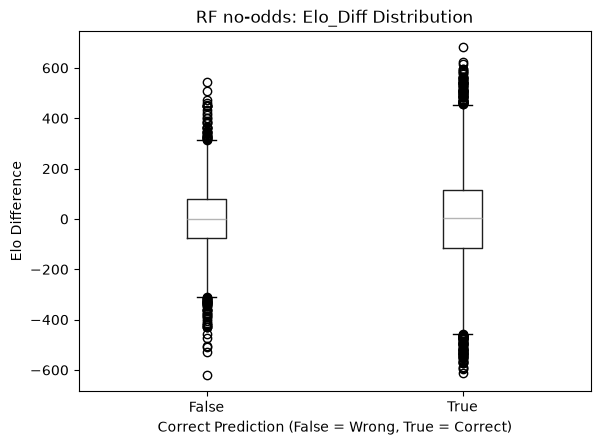

<Figure size 600x400 with 0 Axes>

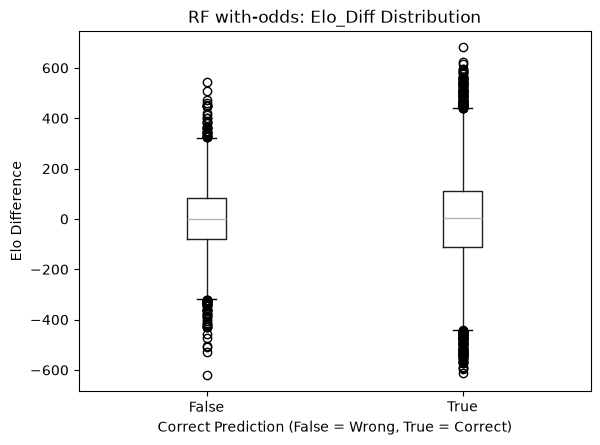

<Figure size 600x400 with 0 Axes>

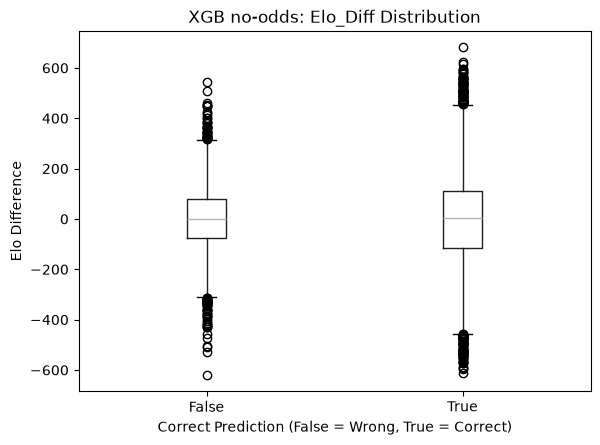

<Figure size 600x400 with 0 Axes>

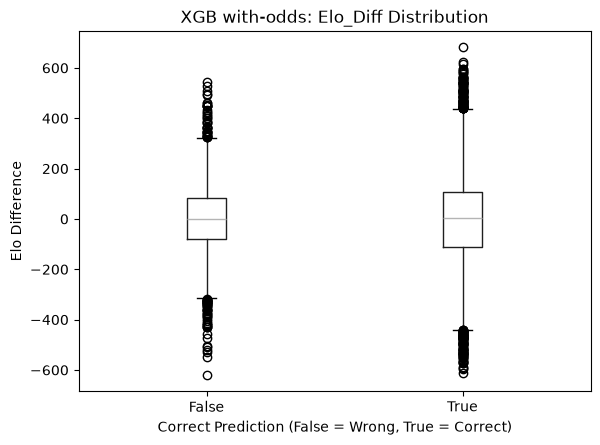

In [169]:
import matplotlib.pyplot as plt

for name, res in results.items():
    comp_df = pd.DataFrame({
        "Correct": res["pred"] == res["y"],
        "Elo_Diff": test_set["Elo_Diff"]
    })
    
    plt.figure(figsize=(6, 4))
    comp_df.boxplot(column="Elo_Diff", by="Correct", grid=False)
    plt.title(f"{name}: Elo_Diff Distribution")
    plt.suptitle("") # Rimuove il sottotitolo automatico di pandas
    plt.xlabel("Correct Prediction (False = Wrong, True = Correct)")
    plt.ylabel("Elo Difference")
    plt.show()

## Most Confident Wrong Matches

In [165]:
def show_most_wrong(name, results, test_set, top_n=10):
    """Show the model's most confident WRONG predictions — useful to spot where it fails."""
    predicted_player_1 = results["pred"] == 1

    wrong = pd.DataFrame({
        "Actual_Winner": np.where(results["y"] == 1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Winner": np.where(predicted_player_1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Loser": np.where(predicted_player_1, test_set["Player_2"], test_set["Player_1"]),
        "Elo_Diff": test_set["Elo_Diff"],
        "Odds_Diff": test_set["Odds_Diff"],
        # Confidence = probability assigned to whichever player the model predicted
        "Confidence": np.where(predicted_player_1, results["proba"], 1 - results["proba"]),
        "Date": test_set["Date"],
    }, index=test_set.index)

    wrong = wrong[results["y"] != results["pred"]]
    wrong = wrong.sort_values("Confidence", ascending=False).head(top_n)

    print(f"{name}: most confident wrong matches")
    display(wrong)


pd.set_option("display.max_columns", None)

for name, model in models.items():
    show_most_wrong(name, results[name], test_set)

RF no-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Elo_Diff,Odds_Diff,Confidence,Date
15950,Cerundolo J.M.,Sinner J.,Cerundolo J.M.,543.267207,-24.99,0.951994,2026-05-28
7950,Seyboth Wild T.,Medvedev D.,Seyboth Wild T.,-456.666800,9.95,0.934386,2023-05-30
4584,Gojowczyk P.,Zverev A.,Gojowczyk P.,338.075004,-8.94,0.927238,2022-02-24
11542,Van De Zandschulp B.,Alcaraz C.,Van De Zandschulp B.,389.583076,-27.99,0.925299,2024-08-30
6084,Galan D.E.,Tsitsipas S.,Galan D.E.,343.469119,-11.96,0.924977,2022-08-30
10964,Comesana F.,Rublev A.,Comesana F.,362.999171,-15.97,0.904661,2024-07-02
16200,Virtanen O.,Shelton B.,Virtanen O.,301.676135,-3.30,0.903292,2026-06-30
9140,Mochizuki S.,Fritz T.,Mochizuki S.,342.430969,-7.93,0.901505,2023-10-19
10545,Tabilo A.,Djokovic N.,Tabilo A.,-470.981685,7.93,0.900342,2024-05-12
1208,Altmaier D.,Berrettini M.,Altmaier D.,-236.952986,3.84,0.899977,2020-10-03


RF with-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Elo_Diff,Odds_Diff,Confidence,Date
15950,Cerundolo J.M.,Sinner J.,Cerundolo J.M.,543.267207,-24.99,0.959919,2026-05-28
6084,Galan D.E.,Tsitsipas S.,Galan D.E.,343.469119,-11.96,0.943553,2022-08-30
7950,Seyboth Wild T.,Medvedev D.,Seyboth Wild T.,-456.666800,9.95,0.937635,2023-05-30
11542,Van De Zandschulp B.,Alcaraz C.,Van De Zandschulp B.,389.583076,-27.99,0.934908,2024-08-30
10033,Nardi L.,Djokovic N.,Nardi L.,-618.660546,15.97,0.934098,2024-03-12
4584,Gojowczyk P.,Zverev A.,Gojowczyk P.,338.075004,-8.94,0.928340,2022-02-24
10545,Tabilo A.,Djokovic N.,Tabilo A.,-470.981685,7.93,0.923602,2024-05-12
15913,Walton A.,Medvedev D.,Walton A.,361.764351,-11.96,0.922403,2026-05-26
12200,Passaro F.,Dimitrov G.,Passaro F.,344.328933,-9.95,0.920507,2025-01-13
4589,Vesely J.,Djokovic N.,Vesely J.,-530.491373,9.95,0.919890,2022-02-24


XGB no-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Elo_Diff,Odds_Diff,Confidence,Date
15950,Cerundolo J.M.,Sinner J.,Cerundolo J.M.,543.267207,-24.99,0.997004,2026-05-28
4589,Vesely J.,Djokovic N.,Vesely J.,-530.491373,9.95,0.995947,2022-02-24
7950,Seyboth Wild T.,Medvedev D.,Seyboth Wild T.,-456.666800,9.95,0.993364,2023-05-30
10033,Nardi L.,Djokovic N.,Nardi L.,-618.660546,15.97,0.988467,2024-03-12
10545,Tabilo A.,Djokovic N.,Tabilo A.,-470.981685,7.93,0.983811,2024-05-12
371,Gulbis E.,Auger Aliassime F.,Gulbis E.,-105.684261,3.11,0.978386,2020-01-21
6331,Goffin D.,Alcaraz C.,Goffin D.,-248.575405,4.88,0.977560,2022-10-04
12099,Opelka R.,Djokovic N.,Opelka R.,-404.370983,9.95,0.973752,2025-01-03
4584,Gojowczyk P.,Zverev A.,Gojowczyk P.,338.075004,-8.94,0.972998,2022-02-24
8618,Monfils G.,Tsitsipas S.,Monfils G.,-154.128408,2.46,0.972934,2023-08-09


XGB with-odds: most confident wrong matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Elo_Diff,Odds_Diff,Confidence,Date
15950,Cerundolo J.M.,Sinner J.,Cerundolo J.M.,543.267207,-24.99,0.994274,2026-05-28
10033,Nardi L.,Djokovic N.,Nardi L.,-618.660546,15.97,0.990926,2024-03-12
4589,Vesely J.,Djokovic N.,Vesely J.,-530.491373,9.95,0.987039,2022-02-24
14405,Griekspoor T.,Sinner J.,Griekspoor T.,-333.894138,17.98,0.985361,2025-10-05
2719,Seppi A.,Auger Aliassime F.,Seppi A.,-110.162907,8.94,0.983571,2021-06-01
10545,Tabilo A.,Djokovic N.,Tabilo A.,-470.981685,7.93,0.982810,2024-05-12
7950,Seyboth Wild T.,Medvedev D.,Seyboth Wild T.,-456.666800,9.95,0.980502,2023-05-30
1420,Sonego L.,Djokovic N.,Sonego L.,507.412209,-13.97,0.979713,2020-10-30
6331,Goffin D.,Alcaraz C.,Goffin D.,-248.575405,4.88,0.978675,2022-10-04
14597,Norrie C.,Alcaraz C.,Norrie C.,-331.453453,9.95,0.977271,2025-10-28


### Most correct matches

In [164]:
def show_most_correct(name, results, test_set, top_n=10):
    """Show the model's most confident CORRECT predictions."""
    predicted_player_1 = results["pred"] == 1

    correct = pd.DataFrame({
        "Actual_Winner": np.where(results["y"] == 1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Winner": np.where(predicted_player_1, test_set["Player_1"], test_set["Player_2"]),
        "Predicted_Loser": np.where(predicted_player_1, test_set["Player_2"], test_set["Player_1"]),
        "Confidence": np.where(predicted_player_1, results["proba"], 1 - results["proba"]),
        "Elo_Diff": test_set["Elo_Diff"],
        "Odds_Diff": test_set["Odds_Diff"],
        "Date": test_set["Date"],
    }, index=test_set.index)

    correct = correct[results["y"] == results["pred"]]
    correct = correct.sort_values("Confidence", ascending=False).head(top_n)

    print(f"{name}: most confident correct matches")
    display(correct)


pd.set_option("display.max_columns", None)

for name, model in models.items():
    show_most_correct(name, results[name], test_set)

RF no-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Confidence,Elo_Diff,Odds_Diff,Date
5305,Djokovic N.,Djokovic N.,Bedene A.,0.957507,465.439491,-19.990,2022-05-27
1193,Djokovic N.,Djokovic N.,Berankis R.,0.956936,-549.190000,-33.029,2020-10-01
2774,Djokovic N.,Djokovic N.,Berankis R.,0.956017,-518.620346,-28.033,2021-06-05
15928,Sinner J.,Sinner J.,Tabur C.,0.950743,585.804210,-66.000,2026-05-26
13274,Alcaraz C.,Alcaraz C.,Zeppieri G.,0.950654,529.676235,-24.990,2025-05-26
1175,Nadal R.,Nadal R.,Mcdonald M.,0.950618,-524.967008,24.990,2020-09-30
3569,Djokovic N.,Djokovic N.,Griekspoor T.,0.949990,-549.589884,24.990,2021-09-03
5243,Djokovic N.,Djokovic N.,Nishioka Y.,0.949816,500.687335,-24.990,2022-05-23
10691,Alcaraz C.,Alcaraz C.,De Jong J.,0.948859,-458.773314,24.990,2024-05-29
10648,Sinner J.,Sinner J.,Eubanks C.,0.948612,-417.497737,17.980,2024-05-27


RF with-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Confidence,Elo_Diff,Odds_Diff,Date
5243,Djokovic N.,Djokovic N.,Nishioka Y.,0.960660,500.687335,-24.990,2022-05-23
5305,Djokovic N.,Djokovic N.,Bedene A.,0.960237,465.439491,-19.990,2022-05-27
10691,Alcaraz C.,Alcaraz C.,De Jong J.,0.956731,-458.773314,24.990,2024-05-29
1175,Nadal R.,Nadal R.,Mcdonald M.,0.956400,-524.967008,24.990,2020-09-30
13274,Alcaraz C.,Alcaraz C.,Zeppieri G.,0.956268,529.676235,-24.990,2025-05-26
14141,Sinner J.,Sinner J.,Kopriva V.,0.955641,-533.197932,50.000,2025-08-26
376,Nadal R.,Nadal R.,Dellien H.,0.955157,-539.859441,27.995,2020-01-21
8813,Djokovic N.,Djokovic N.,Zapata Miralles B.,0.954361,-539.755254,32.990,2023-08-30
14169,Alcaraz C.,Alcaraz C.,Bellucci M.,0.954234,470.507454,-19.980,2025-08-28
12258,Sinner J.,Sinner J.,Schoolkate T.,0.953749,-523.915774,32.990,2025-01-16


XGB no-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Confidence,Elo_Diff,Odds_Diff,Date
14141,Sinner J.,Sinner J.,Kopriva V.,0.998752,-533.197932,50.000,2025-08-26
10688,Djokovic N.,Djokovic N.,Herbert P.H.,0.998632,-473.545975,19.980,2024-05-28
1158,Djokovic N.,Djokovic N.,Ymer M.,0.998565,-568.553736,21.990,2020-09-29
13274,Alcaraz C.,Alcaraz C.,Zeppieri G.,0.997794,529.676235,-24.990,2025-05-26
2774,Djokovic N.,Djokovic N.,Berankis R.,0.997555,-518.620346,-28.033,2021-06-05
11740,Sinner J.,Sinner J.,Daniel T.,0.997442,-471.439878,19.980,2024-10-05
10707,Djokovic N.,Djokovic N.,Carballes Baena R.,0.997384,-496.563066,15.970,2024-05-30
3569,Djokovic N.,Djokovic N.,Griekspoor T.,0.997360,-549.589884,24.990,2021-09-03
6064,Medvedev D.,Medvedev D.,Kozlov S.,0.997356,-451.101154,27.995,2022-08-29
2729,Djokovic N.,Djokovic N.,Sandgren T.,0.997317,529.965844,28.033,2021-06-01


XGB with-odds: most confident correct matches


,Actual_Winner,Predicted_Winner,Predicted_Loser,Confidence,Elo_Diff,Odds_Diff,Date
13638,Sinner J.,Sinner J.,Vukic A.,0.998843,-475.347356,15.99,2025-07-03
8217,Alcaraz C.,Alcaraz C.,Chardy J.,0.998693,-344.047382,27.99,2023-07-04
10950,Sinner J.,Sinner J.,Hanfmann Y.,0.998620,-385.713963,24.99,2024-07-01
8285,Alcaraz C.,Alcaraz C.,Muller A.,0.998371,-402.446888,19.98,2023-07-07
13558,Alcaraz C.,Alcaraz C.,Fognini F.,0.998227,-424.985086,15.99,2025-06-30
1158,Djokovic N.,Djokovic N.,Ymer M.,0.998173,-568.553736,21.99,2020-09-29
11740,Sinner J.,Sinner J.,Daniel T.,0.997587,-471.439878,19.98,2024-10-05
14141,Sinner J.,Sinner J.,Kopriva V.,0.997507,-533.197932,50.00,2025-08-26
2756,Djokovic N.,Djokovic N.,Cuevas P.,0.997403,-445.932755,17.98,2021-06-03
13334,Sinner J.,Sinner J.,Gasquet R.,0.997283,-428.030758,32.99,2025-05-29


Testing accuracy for best ranking players

In [ ]:
market_pred = (test_set["Odds_1"] < test_set["Odds_2"]).to_numpy()
market_valid = test_set["Odds_1"].notna() & test_set["Odds_2"].notna()

for top_n in [10, 50, 100]:
    both_top = (test_set["Rank_1"] <= top_n) & (test_set["Rank_2"] <= top_n)
    mask = both_top & market_valid
    
    market_acc = (market_pred[mask] == y_test[mask]).mean()
    print(f"\n--- Top {top_n} (n={mask.sum()}) | Market: {market_acc:.2%} ---")
    
    # Iterate through all evaluated models
    for name, res in results.items():
        model_acc = (res["pred"][mask] == y_test[mask]).mean()
        print(f"{name}: {model_acc:.2%}")


--- Top 10 (n=353) | Market: 65.16% ---
RF no-odds: 64.87%
RF with-odds: 64.59%
XGB no-odds: 64.31%
XGB with-odds: 65.72%

--- Top 50 (n=4002) | Market: 68.09% ---
RF no-odds: 65.87%
RF with-odds: 67.32%
XGB no-odds: 66.37%
XGB with-odds: 66.99%

--- Top 100 (n=10341) | Market: 67.51% ---
RF no-odds: 64.84%
RF with-odds: 66.87%
XGB no-odds: 65.14%
XGB with-odds: 66.73%


Testing accuracy on Grand Slam matches

In [ ]:
# Maschera per i soli Grand Slam validi per il mercato
gs_mask = (test_set["Series"] == "Grand Slam") & market_valid

market_acc = (market_pred[gs_mask] == y_test[gs_mask]).mean()
print(f"--- Grand Slams (n={gs_mask.sum()}) | Market: {market_acc:.2%} ---")

for name, res in results.items():
    model_acc = (res["pred"][gs_mask] == y_test[gs_mask]).mean()
    print(f"{name}: {model_acc:.2%}")

--- Grand Slams (n=3299) | Market: 74.33% ---
RF no-odds: 71.78%
RF with-odds: 73.36%
XGB no-odds: 71.60%
XGB with-odds: 74.20%
